In [1]:
import axelrod as axl
import numpy as np
from agents.aif.joint_state import AIFJointAgent, SlowLearnAIF, FastLearnAIF, StdLearnAIF
from agents.aif.joint_state import AIFJointAgent, SlowLearnAIF_P2, FastLearnAIF_P2, StdLearnAIF_P2
from agents.aif.joint_state import CustomAIF, SlowLearnAIFNoiseAware, FastLearnAIFNoiseAware, StdLearnAIFNoiseAware 
from agents.aif.factorized import Factorized



Using default B matrix
Using default p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


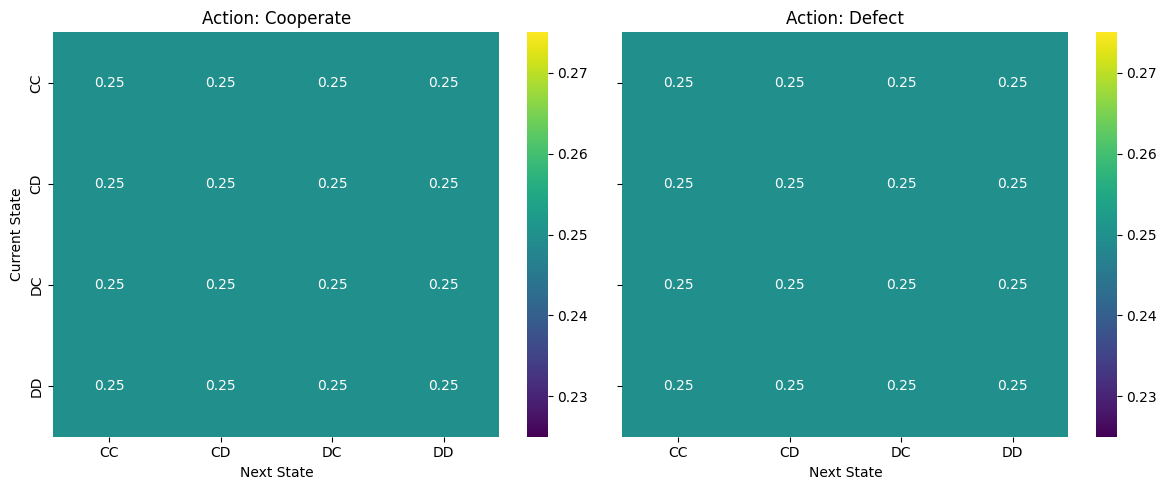

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_transitions(B):
    state_labels = ["CC", "CD", "DC", "DD"]
    action_labels = ["Cooperate", "Defect"]

    b_matrix = B
    # B Matrix Layout is (next_state, current_state, action)

    num_actions = b_matrix.shape[2]
    
    fig, axes = plt.subplots(1, num_actions, figsize=(6 * num_actions, 5), sharey=True, squeeze=False)
    axes = axes.flatten()

    for action_idx, ax in enumerate(axes):
        # We want current_state on Y and next_state on X.
        # b_matrix slice is (next_state, current_state)
        # Transpose it to get (current_state, next_state) for plotting
        transition_probs = b_matrix[:, :, action_idx].T
        
        sns.heatmap(
            transition_probs,
            ax=ax,
            annot=True,
            fmt=".2f",
            cmap="viridis",
            xticklabels=state_labels,
            yticklabels=state_labels,
            cbar=True
        )
        ax.set_title(f"Action: {action_labels[action_idx]}")
        ax.set_xlabel("Next State")
    
    if num_actions > 0:
        axes[0].set_ylabel("Current State")
    
    fig.tight_layout()
    plt.show()


agent = AIFJointAgent()
agent._ensure_agent()
plot_transitions(agent.agent.B[0])

Resetting agent
Using default B matrix
Using default p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent Tit For Tat
995 2 2 1


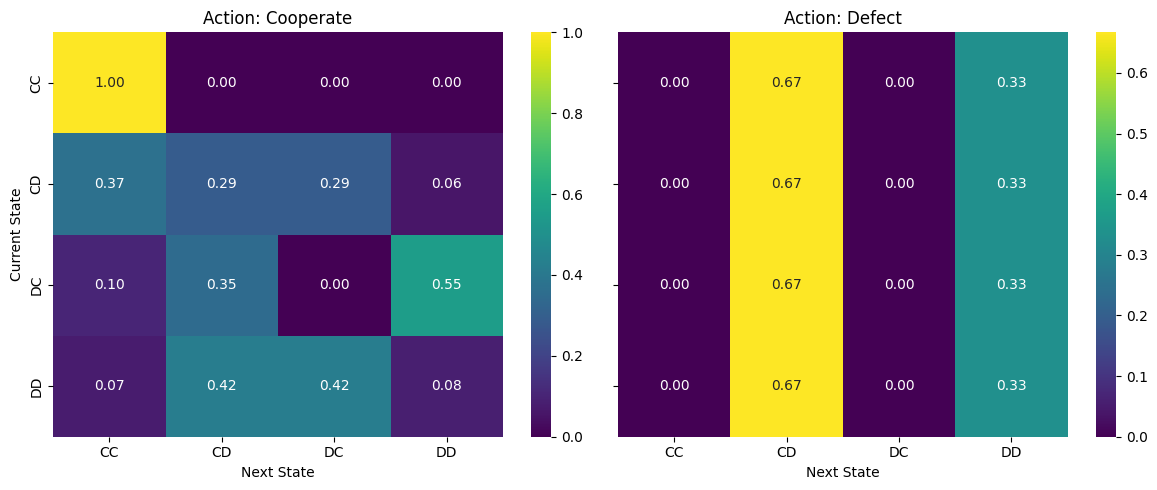

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent GTFT
1000 0 0 0


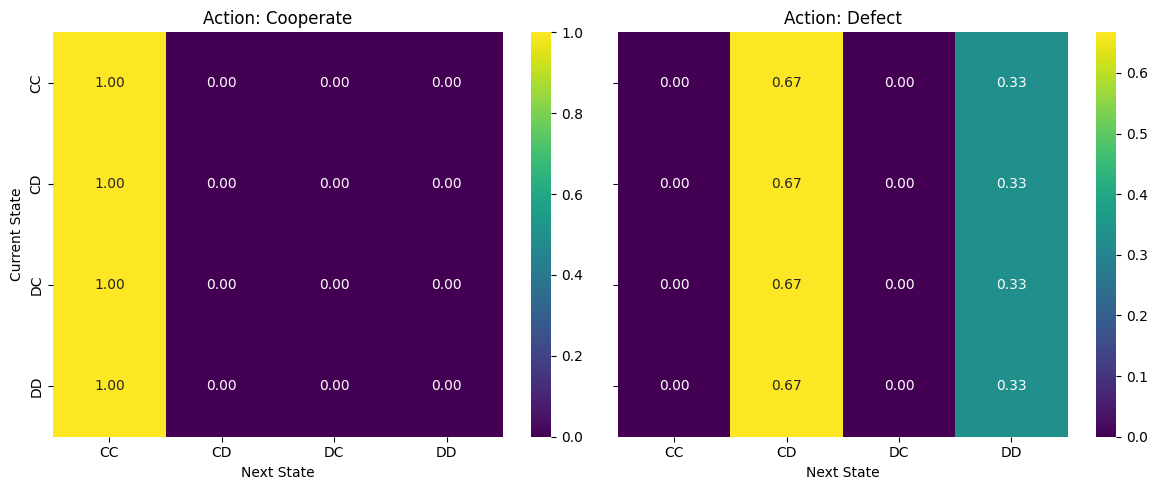

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent Random
504 496 0 0


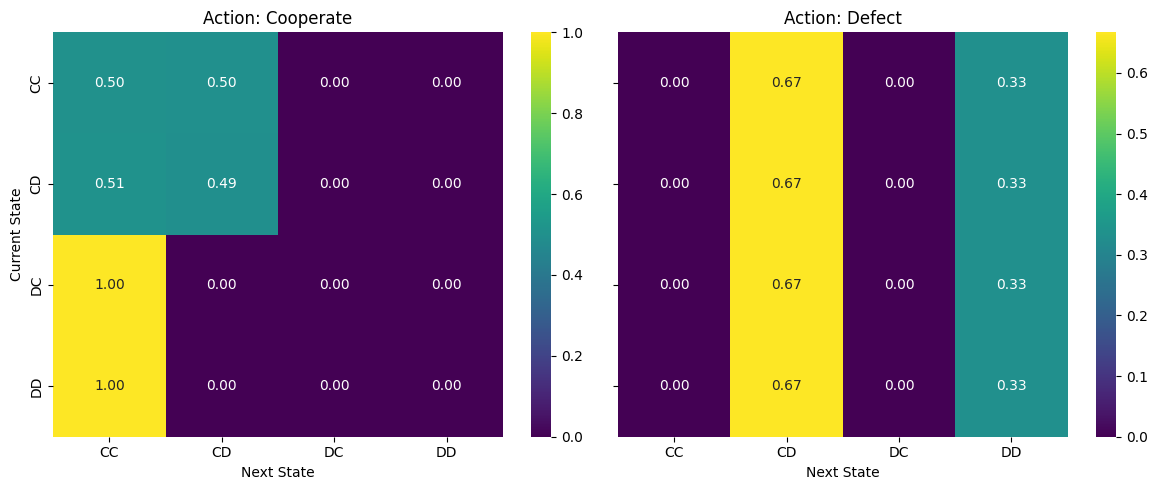

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent Cooperator
1000 0 0 0


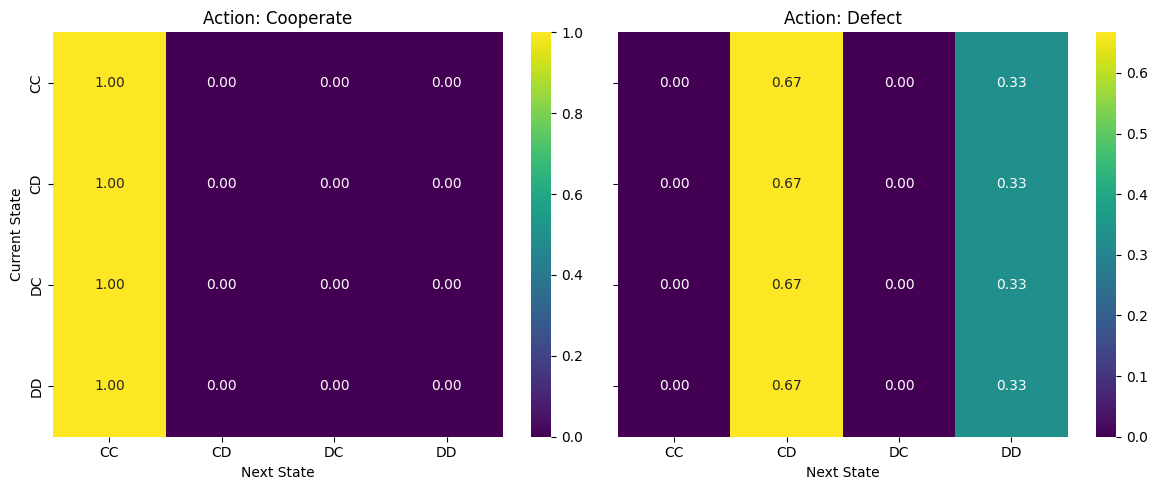

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent Defector
0 999 0 1


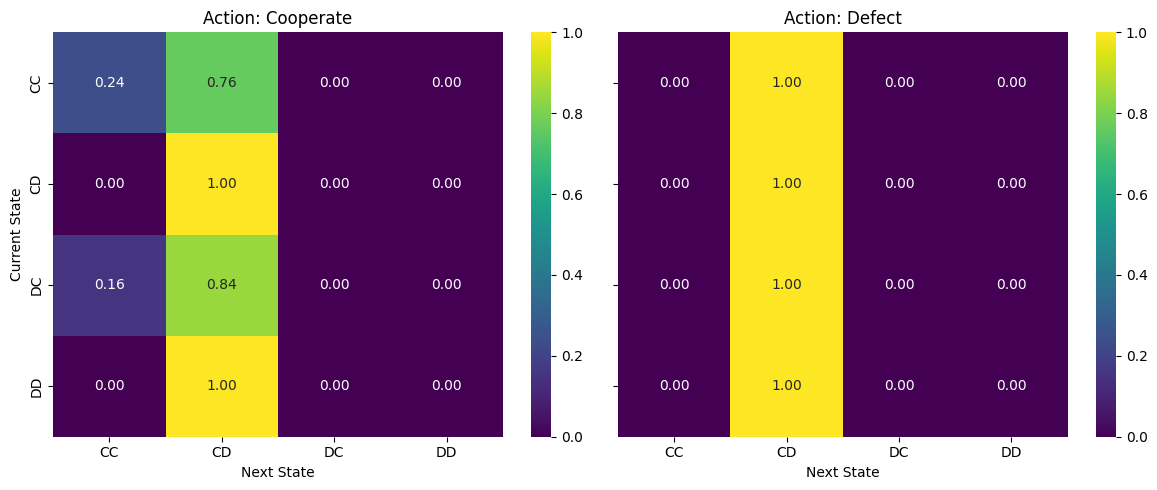

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent Suspicious Tit For Tat
999 1 0 0


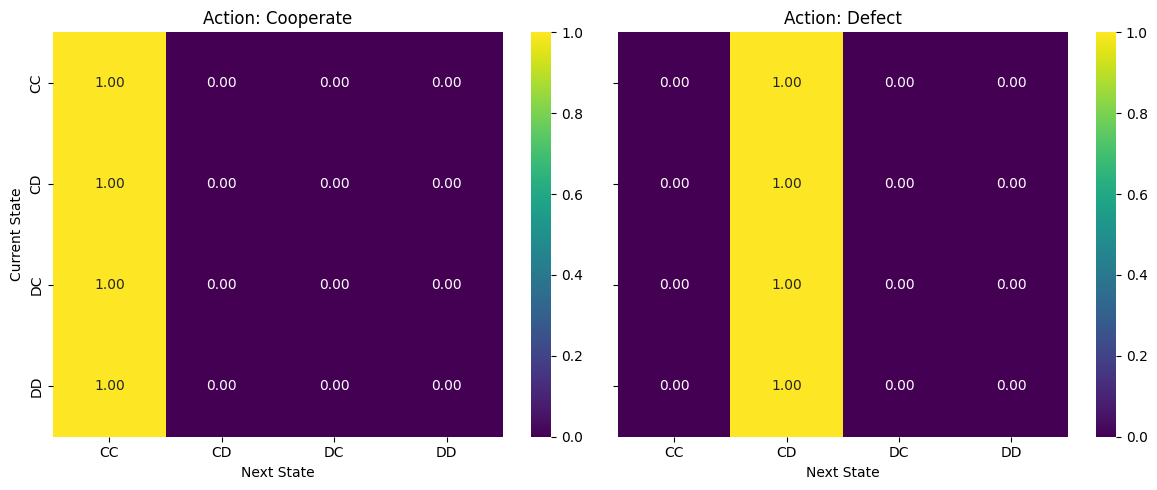

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent Tit For Tat
1000 0 0 0


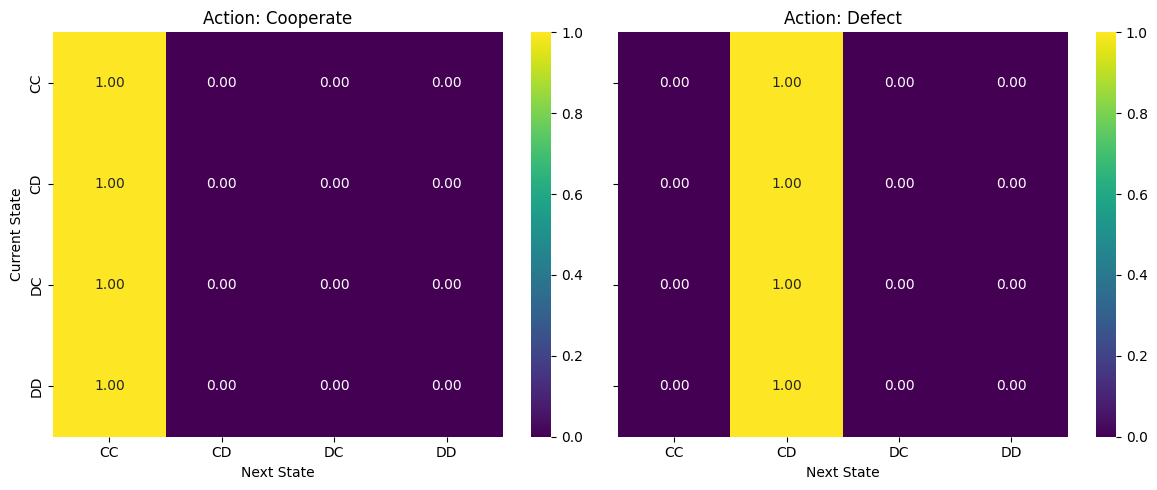

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent GTFT
1000 0 0 0


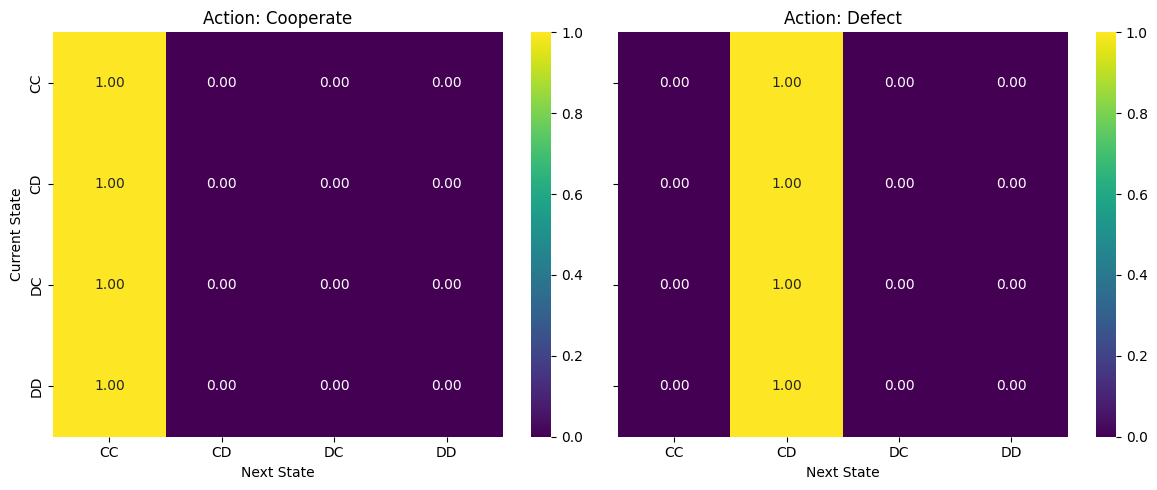

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent Random
525 475 0 0


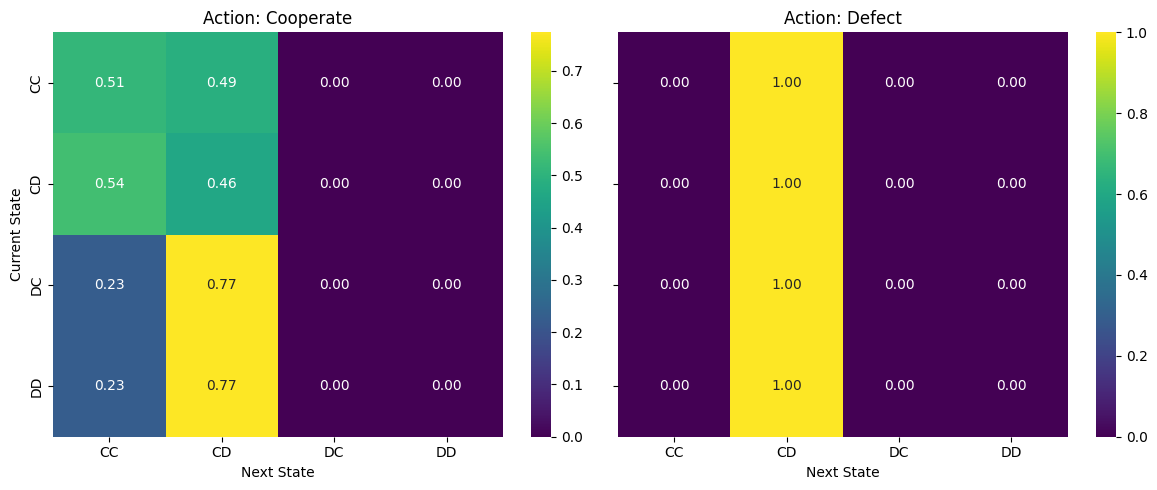

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent Cooperator
1000 0 0 0


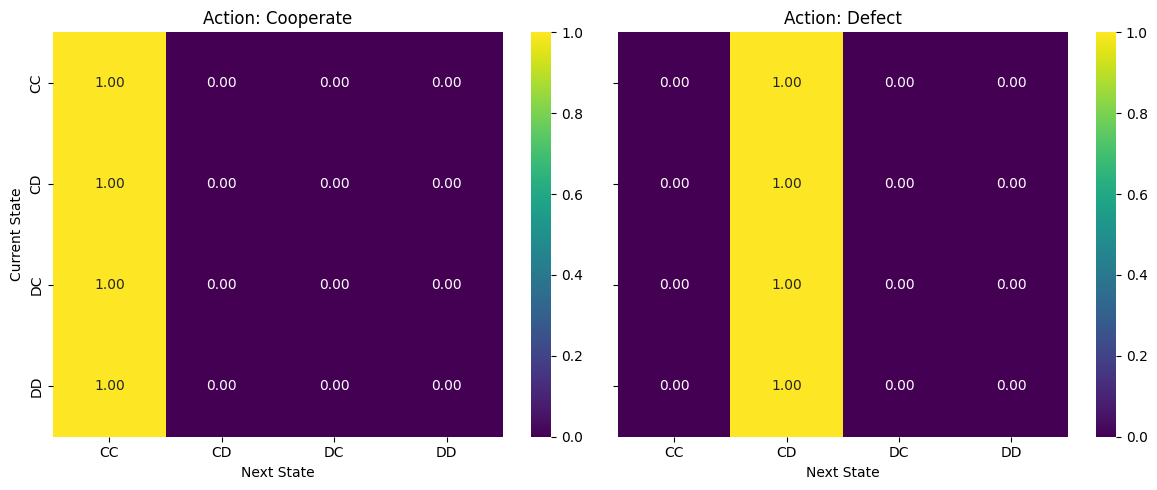

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent Defector
0 1000 0 0


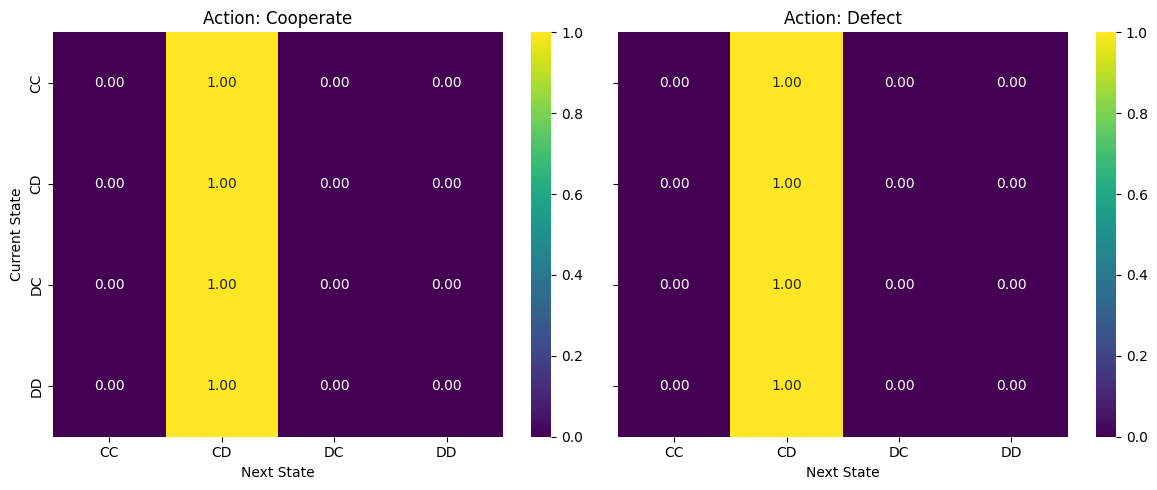

Resetting agent
Using provided B matrix
Using provided p_B matrix


/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


Agent Suspicious Tit For Tat
0 0 0 1000


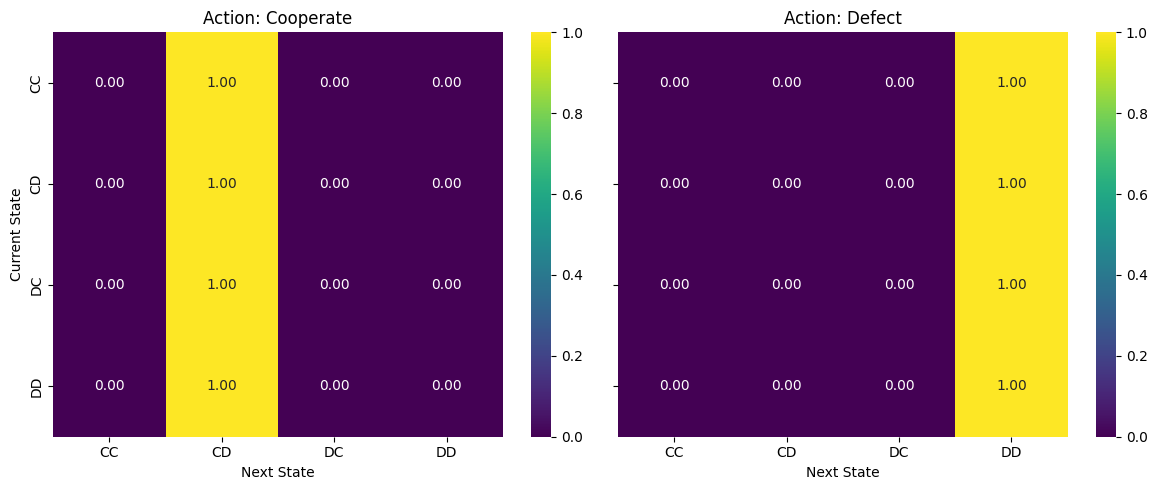

In [4]:
B = None
p_B = None
agent_options = [
    axl.TitForTat(),
    axl.GTFT(),
    axl.Random(),
    axl.Cooperator(),
    axl.Defector(),
    axl.SuspiciousTitForTat(),
    
]
for i in range(12):
    new_agent = AIFJointAgent(B_matrix=B, lr_pB=100, policy_len=1, p_B_matrix=p_B)
    # match = axl.Match((new_agent, axl.GTFT()), turns=10000)
    match = axl.Match((new_agent, agent_options[i % len(agent_options)]), turns=1000)
    res = match.play()
    B = new_agent.agent.B[0]
    p_B = new_agent.agent.pB
    CC_count = 0
    CD_count = 0
    DC_count = 0
    DD_count = 0
    for r in res:
        if str(r[0]) == 'C' and str(r[1]) == 'C':
            CC_count += 1
        elif str(r[0]) == 'C' and str(r[1]) == 'D':
            CD_count += 1
        elif str(r[0]) == 'D' and str(r[1]) == 'C':
            DC_count += 1
        elif str(r[0]) == 'D' and str(r[1]) == 'D':
            DD_count += 1
    print(f"Agent {agent_options[i % len(agent_options)].name}")
    print(CC_count, CD_count, DC_count, DD_count)
    plot_transitions(B)
